In [75]:
import pandas as pd
import matplotlib.pyplot as plt

In [76]:
t1 = pd.read_excel("RunningTimeRecord.xlsx", sheet_name="Testing 1", skiprows=3)

t1.head()

,n,Computational Time (sec),Computational Time (sec).1,Speedup,Computational Time (sec).2,Speedup.1
0,10000000,1.981976,0.664019,2.984818,0.39406,5.02963
1,11000000,2.229783,0.760851,2.930643,0.444861,5.012314
2,12000000,2.526747,0.847935,2.979883,0.503745,5.015925
3,13000000,2.909777,0.93635,3.107574,0.56334,5.165223
4,14000000,3.193509,1.072575,2.977423,0.64324,4.964724


In [77]:
t1_8 = t1.iloc[0:31, [0,3]].copy()

t1_8

,n,Speedup
0,10000000,2.984818
1,11000000,2.930643
2,12000000,2.979883
3,13000000,3.107574
4,14000000,2.977423
5,15000000,3.023201
6,16000000,3.039724
7,17000000,3.022095
8,18000000,2.892885
9,19000000,3.014407


In [78]:
t1_32 = t1.iloc[35:66, [0,3]].copy()

t1_32

,n,Speedup
35,10000000,9.56609
36,11000000,9.877745
37,12000000,10.164212
38,13000000,9.759891
39,14000000,9.96702
40,15000000,9.176484
41,16000000,7.850593
42,17000000,7.639998
43,18000000,10.145479
44,19000000,10.964184


In [79]:
df1 = pd.merge(t1_8, t1_32, on='n')

df1.rename(
    columns={
        "Speedup_x": "speedup_8cores",
        "Speedup_y": "speedup_32cores"
    },
    inplace=True
)

df1

,n,speedup_8cores,speedup_32cores
0,10000000,2.984818,9.56609
1,11000000,2.930643,9.877745
2,12000000,2.979883,10.164212
3,13000000,3.107574,9.759891
4,14000000,2.977423,9.96702
5,15000000,3.023201,9.176484
6,16000000,3.039724,7.850593
7,17000000,3.022095,7.639998
8,18000000,2.892885,10.145479
9,19000000,3.014407,10.964184


In [80]:
t2 = pd.read_excel("RunningTimeRecord.xlsx", sheet_name="Testing 2", skiprows=3)

t2.head()

,Num Threads,Computational Time (sec),Computational Time (sec).1,Speedup,Computational Time (sec).2
0,1,1.981976,1.998806,0.99158,2.050615
1,4,1.981976,1.163114,1.704026,0.620855
2,8,1.981976,0.663606,2.986676,0.397514
3,16,1.981976,0.445718,4.446704,0.393962
4,32,1.981976,0.446779,4.436144,0.405892


In [81]:
t2_8 = t2.iloc[0:6, [0,3]].copy()

t2_8.rename(columns={"Speedup": "speedup_8cores"},
           inplace=True)

t2_8.reset_index(drop=True, inplace=True)

t2_8

,Num Threads,speedup_8cores
0,1,0.99158
1,4,1.704026
2,8,2.986676
3,16,4.446704
4,32,4.436144
5,64,4.452158


In [82]:
t2_32 = t2.iloc[11:17, [0,3]].copy()

t2_32.rename(columns={"Speedup": "speedup_32cores"},
           inplace=True)

t2_32.reset_index(drop=True, inplace=True)

t2_32

,Num Threads,speedup_32cores
0,1,1.072583
1,4,2.093458
2,8,4.632264
3,16,7.692852
4,32,10.256392
5,64,10.889911


In [83]:
df2 = pd.merge(t2_8, t2_32, on='Num Threads')

df2.rename(columns={"Num Threads": "num_threads"}, inplace=True)

df2

,num_threads,speedup_8cores,speedup_32cores
0,1,0.99158,1.072583
1,4,1.704026,2.093458
2,8,2.986676,4.632264
3,16,4.446704,7.692852
4,32,4.436144,10.256392
5,64,4.452158,10.889911


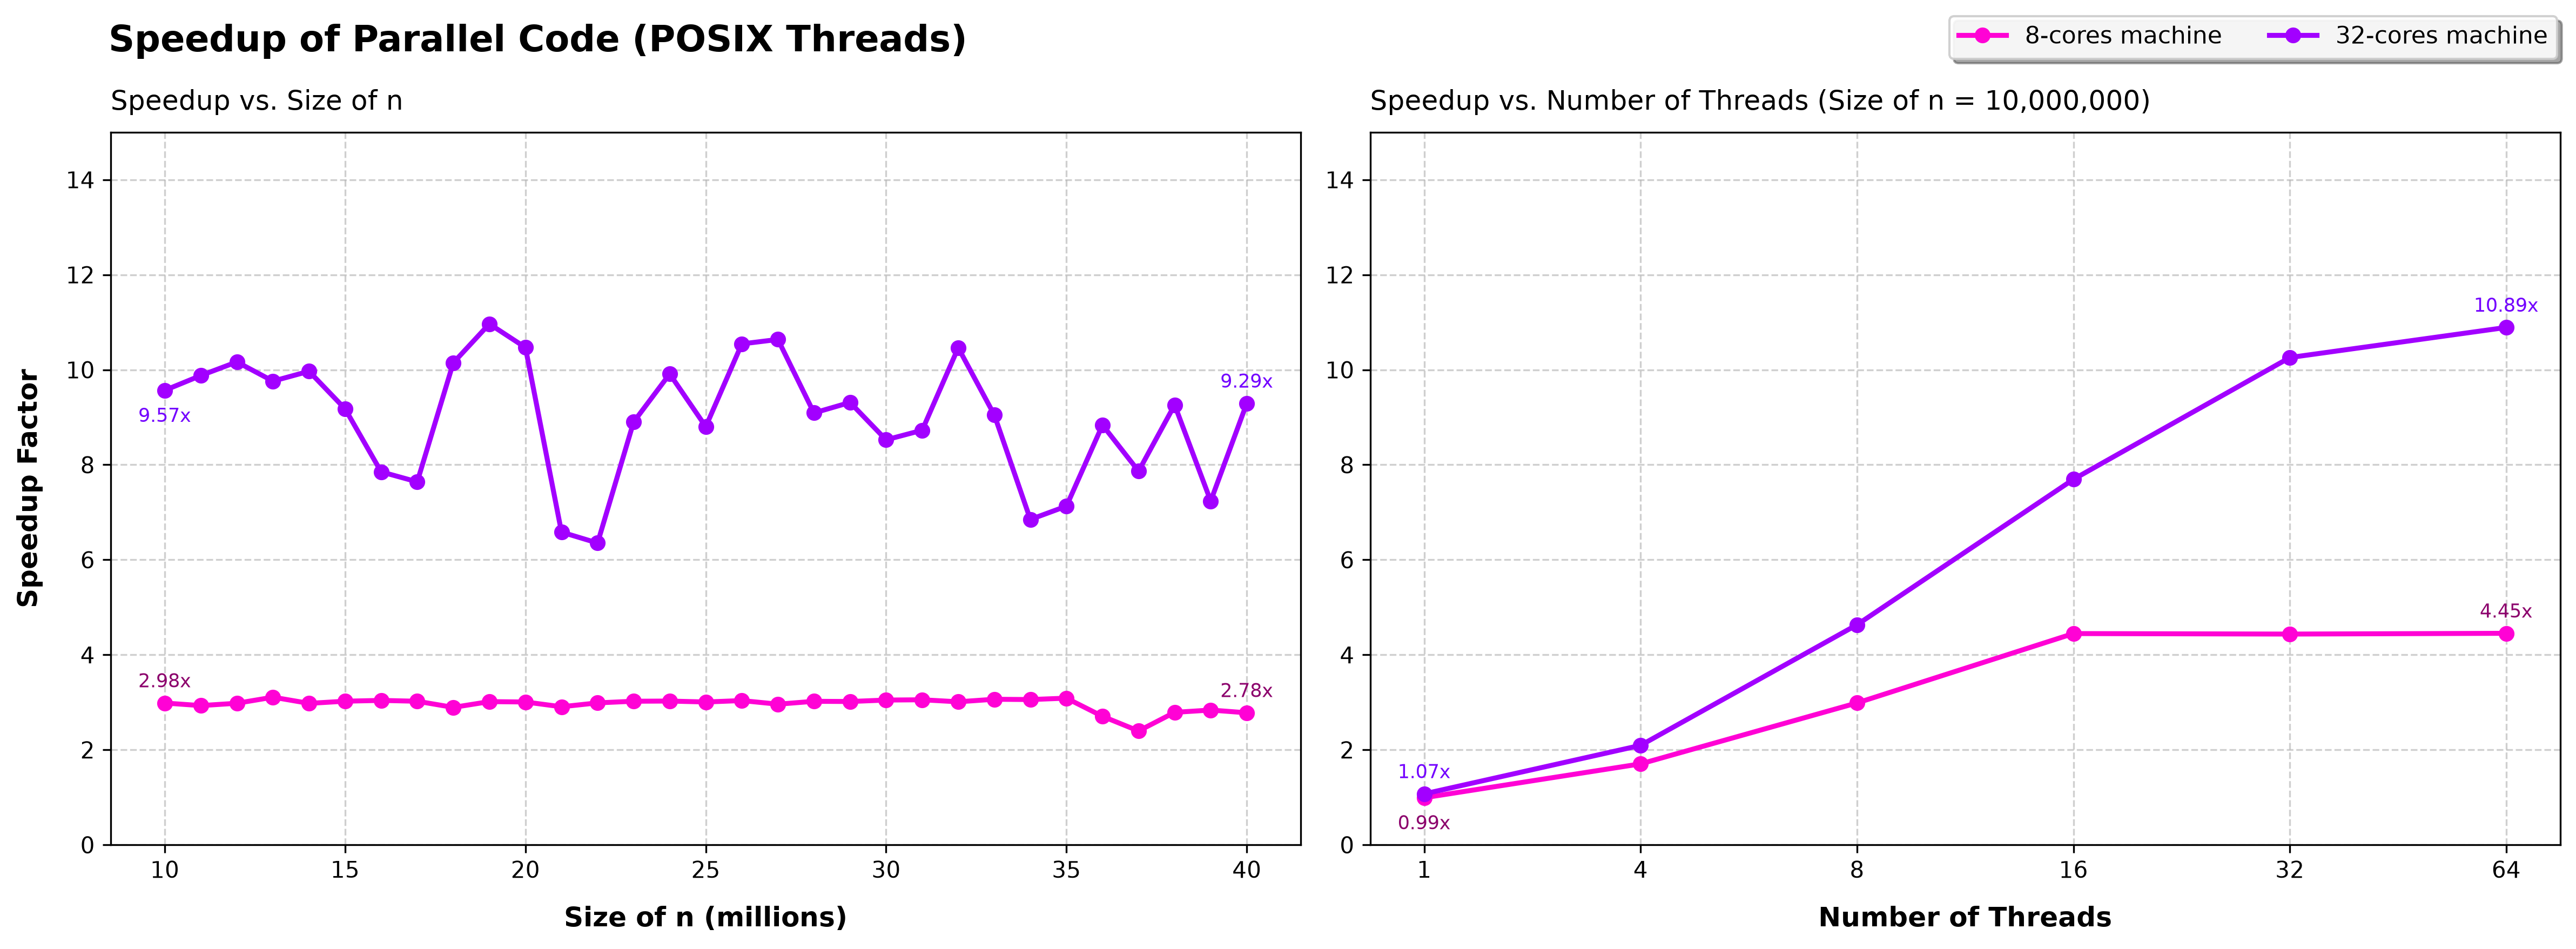

In [84]:
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator, FuncFormatter

fig, axes = plt.subplots(1, 2, figsize=(16, 6), dpi=300)

# =============================================================
# Graph 1 (df1): Speedup vs. Size of n (Fixed 8 Threads)
# =============================================================
ax = axes[0]

# 8-core machine speedup
line1, = ax.plot(df1.n, df1.speedup_8cores,
                 marker='o', markersize=6, linewidth=2.2,
                 color="#FF02D5", label='8-cores machine')

# 32-core machine speedup
line2, = ax.plot(df1.n, df1.speedup_32cores,
                 marker='o', markersize=6, linewidth=2.2,
                 color="#A200FF", label='32-cores machine')

ax.set_title("Speedup vs. Size of n",
             fontsize=12, loc='left', pad=10)

ax.set_xlabel("Size of n (millions)",
              fontsize=12, fontweight='semibold', labelpad=10)

ax.set_ylabel("Speedup Factor",
              fontsize=12, fontweight='semibold', labelpad=10)

# X-axis: keep all data points, but show ticks/grid every 5 million
ax.xaxis.set_major_locator(MultipleLocator(5_000_000))
ax.xaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f"{x / 1_000_000:g}")
)

ax.tick_params(axis='x', labelsize=10)
ax.tick_params(axis='y', labelsize=10)

ax.grid(True, linestyle='--', alpha=0.6)
ax.set_ylim(0, 15)

ax.annotate(f"{df1.speedup_8cores.iloc[0]:.2f}x",
            (df1.n.iloc[0], df1.speedup_8cores.iloc[0]),
            textcoords='offset points', xytext=(0, 7), ha='center',
            fontsize=8.5, color="#8C016C")

ax.annotate(f"{df1.speedup_8cores.iloc[-1]:.2f}x",
            (df1.n.iloc[-1], df1.speedup_8cores.iloc[-1]),
            textcoords='offset points', xytext=(0, 7), ha='center',
            fontsize=8.5, color="#8C016C")

ax.annotate(f"{df1.speedup_32cores.iloc[0]:.2f}x",
            (df1.n.iloc[0], df1.speedup_32cores.iloc[0]),
            textcoords='offset points', xytext=(0, -14), ha='center',
            fontsize=8.5, color="#7300FF")

ax.annotate(f"{df1.speedup_32cores.iloc[-1]:.2f}x",
            (df1.n.iloc[-1], df1.speedup_32cores.iloc[-1]),
            textcoords='offset points', xytext=(0, 7), ha='center',
            fontsize=8.5, color="#7300FF")


# =============================================================
# Graph 2 (df2): Speedup vs. Number of Threads (Fixed n = 10M)
# =============================================================
ax = axes[1]

# 8-core machine speedup
ax.plot(range(len(df2.num_threads)), df2.speedup_8cores,
        marker='o', markersize=6, linewidth=2.2,
        color="#FF02D5")

# 32-core machine speedup
ax.plot(range(len(df2.num_threads)), df2.speedup_32cores,
        marker='o', markersize=6, linewidth=2.2,
        color="#A200FF")

ax.set_title("Speedup vs. Number of Threads (Size of n = 10,000,000)",
             fontsize=12, loc='left', pad=10)

ax.set_xlabel("Number of Threads",
              fontsize=12, fontweight='semibold', labelpad=10)

ax.set_xticks(range(len(df2.num_threads)))
ax.set_xticklabels(df2.num_threads, fontsize=10)

ax.tick_params(axis='y', labelsize=10)
ax.grid(True, linestyle='--', alpha=0.6)
ax.set_ylim(0, 15)

ax.annotate(f"{df2.speedup_8cores.iloc[0]:.2f}x",
            (0, df2.speedup_8cores.iloc[0]),
            textcoords='offset points', xytext=(0, -14), ha='center',
            fontsize=8.5, color="#8C016C")

ax.annotate(f"{df2.speedup_8cores.iloc[-1]:.2f}x",
            (len(df2.num_threads) - 1, df2.speedup_8cores.iloc[-1]),
            textcoords='offset points', xytext=(0, 7), ha='center',
            fontsize=8.5, color="#8C016C")

ax.annotate(f"{df2.speedup_32cores.iloc[0]:.2f}x",
            (0, df2.speedup_32cores.iloc[0]),
            textcoords='offset points', xytext=(0, 7), ha='center',
            fontsize=8.5, color="#7300FF")

ax.annotate(f"{df2.speedup_32cores.iloc[-1]:.2f}x",
            (len(df2.num_threads) - 1, df2.speedup_32cores.iloc[-1]),
            textcoords='offset points', xytext=(0, 7), ha='center',
            fontsize=8.5, color="#7300FF")


# =========================
# Overall title
# =========================
fig.suptitle(
    "Speedup of Parallel Code (POSIX Threads)",
    fontsize=16,
    fontweight='bold',
    x=0.045,
    y=0.96,
    ha='left'
)

# =========================
# Unified Global Legend
# =========================
fig.legend(
    handles=[line1, line2],
    labels=['8-cores machine', '32-cores machine'],
    loc='upper right',
    bbox_to_anchor=(0.994, 0.98),
    ncol=2,
    fontsize=10.5,
    frameon=True,
    framealpha=0.9,
    shadow=True
)

plt.tight_layout(rect=[0, 0, 1, 0.98])

plt.savefig("task2_graph3.png", dpi=300)
plt.show()